# Truth information and four-momentum conservation

> **Advanced extension.** For an introductory treatment, start with the [companion lesson](w_to_munu_truth_met_69747.ipynb) on the visible muon, invisible neutrino, and missing transverse momentum.

This notebook studies the hard collision and a later $W$ decay in one file from the CMS simulated **W+jets** dataset [CERN Open Data record 69747](https://opendata.cern.ch/record/cms-69747).

The central question is whether the incoming and outgoing particles satisfy

$$\sum_{\mathrm{incoming}} p^\mu = \sum_{\mathrm{outgoing}} p^\mu,$$

where $p^\mu=(E,p_x,p_y,p_z)$.

The dataset is inclusive in $W\to\ell\nu$: it contains electron, muon, and tau channels. Its matrix element includes $W+0$ through $4$ outgoing partons, combined with a parton shower using MLM matching. We will deliberately choose one unusually simple $W\to\mu\nu$ event so that the conservation calculation is easy to see.

## A diagram is not an event record

The pictures below are **representative tree-level topologies**, not a claim that every event follows one uniquely identifiable diagram. Read them from left to right: straight lines are quarks or leptons, curly lines are gluons, and wavy lines are W bosons. Fermion arrows follow the particle/antiparticle convention rather than simply indicating time. Quantum amplitudes from compatible diagrams are added before probabilities are calculated.

| View | What it represents |
| --- | --- |
| Feynman diagram | A contribution to the quantum amplitude; it may contain an internal $W$ line |
| `LHEPart` | External incoming and outgoing particles from the matrix-element calculation; the internal $W$ need not be a row |
| `GenPart` | A selected, pruned generator history after showering and decays; successive copies of a particle may appear |

The production and decay panels can be joined at their W line; in the combined process the W is an internal propagator, so `LHEPart` may list only the external quarks/gluons, charged lepton, and neutrino. The production pictures show examples with one outgoing parton. The official [process card](https://opendata.cern.ch/eos/opendata/cms/lhe_generators/2016-sim/gridpacks/69747/InputCards/WJetsToLNu_13TeV-madgraphMLM-pythia8_proc_card.dat) defines $pp\to\ell\nu+0,1,2,3,4$ partons. The [branch documentation for this exact file](https://opendata.cern.ch/eos/opendata/cms/dataset-semantics/NanoAODSIM/69747/WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8_doc.html) is the reference for the stored column meanings.

In [1]:
# @title Representative W production and decay diagrams
from IPython.display import HTML

diagram_base = "https://atlas.physicsmasterclasses.org/wpath_files/img/Feynman"
diagram_cards = [
    ("u + g → d + W⁺ (one-parton example)", f"{diagram_base}/WplusDown.png"),
    ("W⁺ → μ⁺ + νμ", f"{diagram_base}/Wplus_Antimyon.png"),
    ("d + g → u + W⁻ (one-parton example)", f"{diagram_base}/WminusUp.png"),
    ("W⁻ → μ⁻ + ν̄μ", f"{diagram_base}/Wminus_Myon.png"),
]
cards_html = "".join(
    f"<figure style='margin:0;text-align:center'><img src='{url}' alt='{caption}' "
    f"style='width:100%;max-height:260px;object-fit:contain'><figcaption>{caption}</figcaption></figure>"
    for caption, url in diagram_cards
)
HTML(
    f"<div style='display:grid;grid-template-columns:repeat(2,minmax(260px,1fr));gap:18px'>{cards_html}</div>"
    "<p style='font-size:0.85em;color:#475569'>Source and image credit: "
    "<a href='https://atlas.physicsmasterclasses.org/en/wpath_lhcphysics2.htm'>ATLAS W-Path, "
    "International Physics Masterclasses</a>. See the "
    "<a href='https://ippog.org/ippog-copyright'>IPPOG educational-use terms</a>.</p>"
)

## Which truth record should we use?

The protons collide at $\sqrt{s}=13\ \mathrm{TeV}$, so each proton beam has energy $E_{\rm beam}=6.5\ \mathrm{TeV}$. The hard collision is between **partons** inside the protons. They carry event-dependent momentum fractions $x_1$ and $x_2$:

$$p_1^\mu \simeq (x_1E_{\rm beam},0,0,+x_1E_{\rm beam}),\qquad
p_2^\mu \simeq (x_2E_{\rm beam},0,0,-x_2E_{\rm beam}).$$

For a global conservation test, `LHEPart` is the clean record. Its status is `-1` for incoming particles and `1` for outgoing particles, and `LHEPart_incomingpz` stores the incoming longitudinal momentum. The later `GenPart` collection contains shower and decay history, with multiple copies of some particles, but only the subset considered “interesting” by NanoAOD. Summing every `GenPart` would therefore double-count history entries while also omitting other particles.

Both are commonly called “truth,” but they describe different stages and neither is a literal, complete list of everything that physically happened.

In [2]:
from pathlib import Path
import html
import importlib.util
import shutil
import subprocess
import sys

# Install only dependencies that are missing from the current environment.
required_packages = {
    "awkward": "awkward==2.12.0", "uproot": "uproot==5.7.5",
    "graphviz": "graphviz==0.21", "particle": "particle==1.0.0",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
if shutil.which("dot") is None:
    if importlib.util.find_spec("google.colab") is not None:
        subprocess.run(["apt-get", "update", "-qq"], check=True)
        subprocess.run(["apt-get", "install", "-y", "-qq", "graphviz"], check=True)
    else:
        raise RuntimeError("Graphviz 'dot' is required (for example: brew install graphviz).")

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot
from graphviz import Digraph
from IPython.display import Markdown, display
from particle import Particle, ParticleNotFound

filename = "00702195-E707-3743-8BBA-57EB9DEE1DBA.root"
file_url = (
    "https://opendata.cern.ch/eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/"
    "WJetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8/NANOAODSIM/"
    "106X_mcRun2_asymptotic_v17-v1/270000/" + filename
)
# Reuse a local copy when available; otherwise download into the working directory.
candidates = [Path("data/69747") / filename, Path("../data/69747") / filename, Path(filename)]
file_path = next((path.resolve() for path in candidates if path.exists()), None)
if file_path is None:
    file_path = Path(filename).resolve()
    subprocess.run(["curl", "-L", "--fail", "--retry", "3", "--output", str(file_path), file_url], check=True)

print(f"Uproot {uproot.__version__}; Awkward {ak.__version__}")
print(f"Input: {file_path.name}")

Uproot 5.7.5; Awkward 2.12.0
Input: 00702195-E707-3743-8BBA-57EB9DEE1DBA.root


In [3]:
PARTICLE_NAMES = {
    1: "d", -1: "d̄", 2: "u", -2: "ū", 3: "s", -3: "s̄",
    4: "c", -4: "c̄", 5: "b", -5: "b̄", 21: "g",
    11: "e⁻", -11: "e⁺", 12: "νₑ", -12: "ν̄ₑ",
    13: "μ⁻", -13: "μ⁺", 14: "νμ", -14: "ν̄μ",
    15: "τ⁻", -15: "τ⁺", 16: "ντ", -16: "ν̄τ",
    22: "γ", 23: "Z", 24: "W⁺", -24: "W⁻",
}

def particle_name(pdg_id):
    return PARTICLE_NAMES.get(int(pdg_id), str(int(pdg_id)))

def display_table(headers, rows):
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

## Read the hard-scattering record

In [4]:
root_file = uproot.open(file_path)
events = root_file["Events"]

# LHEPart is jagged: each event has its own list of incoming and outgoing particles.
lhe_branches = [
    "event",
    "Generator_x1", "Generator_x2", "Generator_id1", "Generator_id2",
    "LHEPart_pt", "LHEPart_eta", "LHEPart_phi", "LHEPart_mass",
    "LHEPart_incomingpz", "LHEPart_pdgId", "LHEPart_status",
]
lhe = events.arrays(lhe_branches, library="ak")

incoming_counts = ak.num(lhe.LHEPart_pdgId[lhe.LHEPart_status == -1])
outgoing_counts = ak.num(lhe.LHEPart_pdgId[lhe.LHEPart_status == 1])
assert bool(ak.all(incoming_counts == 2))
print(f"Loaded {len(lhe):,} events")
print("Incoming particles per event: 2 (verified for every event)")
print("Outgoing particles per event range from", int(ak.min(outgoing_counts)),
      "to", int(ak.max(outgoing_counts)))

Loaded 133,692 events
Incoming particles per event: 2 (verified for every event)
Outgoing particles per event range from 2 to 6


## Construct every LHE four-vector

For an outgoing particle described by $(p_T,\eta,\phi,m)$,

$$p_x=p_T\cos\phi,\quad p_y=p_T\sin\phi,\quad p_z=p_T\sinh\eta,\quad
E=\sqrt{(p_T\cosh\eta)^2+m^2}.$$

Incoming partons have zero transverse momentum here, so their energy is calculated from the stored `incomingpz`.

In [5]:
# Promote packed NanoAOD floats before doing the arithmetic.
pt = ak.values_astype(lhe.LHEPart_pt, np.float64)
eta = ak.values_astype(lhe.LHEPart_eta, np.float64)
phi = ak.values_astype(lhe.LHEPart_phi, np.float64)
mass = ak.values_astype(lhe.LHEPart_mass, np.float64)
incoming_pz = ak.values_astype(lhe.LHEPart_incomingpz, np.float64)

is_incoming = lhe.LHEPart_status == -1
is_outgoing = lhe.LHEPart_status == 1

p4 = ak.zip({
    "E": ak.where(
        is_incoming,
        np.sqrt(incoming_pz**2 + mass**2),
        np.sqrt((pt * np.cosh(eta))**2 + mass**2),
    ),
    "px": pt * np.cos(phi),
    "py": pt * np.sin(phi),
    "pz": ak.where(is_incoming, incoming_pz, pt * np.sinh(eta)),
})

def sum_four_vectors(mask):
    return ak.zip({field: ak.sum(p4[field][mask], axis=1) for field in p4.fields})

incoming_total = sum_four_vectors(is_incoming)
outgoing_total = sum_four_vectors(is_outgoing)
residual = ak.zip({
    field: incoming_total[field] - outgoing_total[field]
    for field in p4.fields
})

## One especially clear event

Select a hard collision with exactly one muon and one muon-neutrino in the LHE final state and with similarly sized momentum fractions from the two protons. “No LHE parton” does **not** mean that the later parton shower contains no radiation or that the reconstructed event contains no jets.

In [6]:
# Pick a visually simple μν event for the worked four-momentum example.
outgoing_abs_id = abs(lhe.LHEPart_pdgId[is_outgoing])
outgoing_muon_count = ak.sum(outgoing_abs_id == 13, axis=1)
outgoing_muon_neutrino_count = ak.sum(outgoing_abs_id == 14, axis=1)
is_simple_muon_event = (
    (ak.num(outgoing_abs_id, axis=1) == 2)
    & (outgoing_muon_count == 1)
    & (outgoing_muon_neutrino_count == 1)
    & ak.all(abs(lhe.LHEPart_eta[is_outgoing]) < 2.5, axis=1)
    & (abs(np.log(lhe.Generator_x1 / lhe.Generator_x2)) < 0.2)
)
event_index = int(np.flatnonzero(ak.to_numpy(is_simple_muon_event))[0])

print(f"Entry {event_index}; event number {int(lhe.event[event_index])}")
print(f"x₁ = {float(lhe.Generator_x1[event_index]):.6f}")
print(f"x₂ = {float(lhe.Generator_x2[event_index]):.6f}")

Entry 42; event number 6053913
x₁ = 0.005875
x₂ = 0.006526


In [7]:
particle_rows = []
for particle_index in range(len(lhe.LHEPart_pdgId[event_index])):
    role = "incoming" if bool(is_incoming[event_index, particle_index]) else "outgoing"
    particle_rows.append([
        particle_index,
        role,
        particle_name(lhe.LHEPart_pdgId[event_index, particle_index]),
        int(lhe.LHEPart_pdgId[event_index, particle_index]),
        f"{float(p4.E[event_index, particle_index]):.4f}",
        f"{float(p4.px[event_index, particle_index]):+.4f}",
        f"{float(p4.py[event_index, particle_index]):+.4f}",
        f"{float(p4.pz[event_index, particle_index]):+.4f}",
    ])

display_table(
    ["index", "role", "particle", "PDG ID", "E [GeV]", "px [GeV]", "py [GeV]", "pz [GeV]"],
    particle_rows,
)

| index | role | particle | PDG ID | E [GeV] | px [GeV] | py [GeV] | pz [GeV] |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | incoming | ū | -2 | 38.1836 | +0.0000 | +0.0000 | +38.1836 |
| 1 | incoming | d | 1 | 42.4199 | +0.0000 | +0.0000 | -42.4199 |
| 2 | outgoing | μ⁻ | 13 | 40.9108 | -38.0400 | +6.2304 | -13.7051 |
| 3 | outgoing | ν̄μ | -14 | 39.6931 | +38.0400 | -6.2305 | +9.4701 |

In [8]:
balance_rows = []
for label, total in [
    ("Σ incoming", incoming_total),
    ("Σ outgoing", outgoing_total),
    ("incoming − outgoing", residual),
]:
    balance_rows.append([
        label,
        *[f"{float(total[field][event_index]):+.6f}" for field in ["E", "px", "py", "pz"]],
    ])

display_table(["sum", "E [GeV]", "px [GeV]", "py [GeV]", "pz [GeV]"], balance_rows)

def invariant_mass(total):
    mass_squared = total.E**2 - total.px**2 - total.py**2 - total.pz**2
    return np.sqrt(np.maximum(ak.to_numpy(mass_squared), 0.0))

mass_in = invariant_mass(incoming_total)
mass_out = invariant_mass(outgoing_total)
sqrt_s_from_x = 13_000.0 * np.sqrt(
    ak.to_numpy(lhe.Generator_x1) * ak.to_numpy(lhe.Generator_x2)
)

print(f"Partonic √ŝ from incoming LHE four-vector: {mass_in[event_index]:.4f} GeV")
print(f"Partonic √ŝ from 13 TeV × √(x₁x₂):       {sqrt_s_from_x[event_index]:.4f} GeV")
print(f"Invariant mass of outgoing system:       {mass_out[event_index]:.4f} GeV")

| sum | E [GeV] | px [GeV] | py [GeV] | pz [GeV] |
| --- | --- | --- | --- | --- |
| Σ incoming | +80.603516 | +0.000000 | +0.000000 | -4.236328 |
| Σ outgoing | +80.603903 | -0.000008 | -0.000049 | -4.235009 |
| incoming − outgoing | -0.000387 | +0.000008 | +0.000049 | -0.001319 |

Partonic √ŝ from incoming LHE four-vector: 80.4921 GeV
Partonic √ŝ from 13 TeV × √(x₁x₂):       80.4943 GeV
Invariant mass of outgoing system:       80.4926 GeV


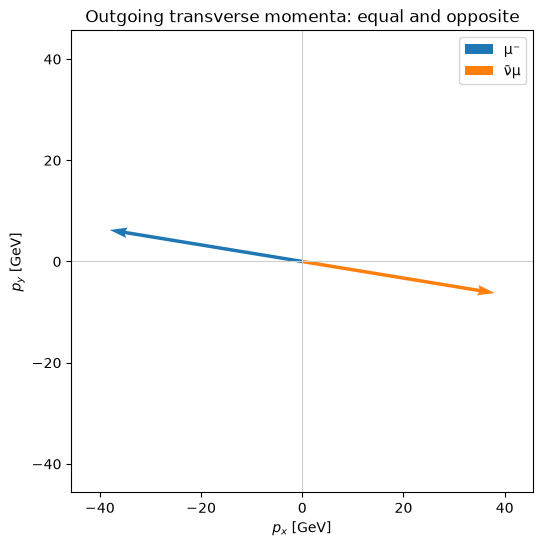

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
outgoing_indices = np.flatnonzero(ak.to_numpy(is_outgoing[event_index]))

colors = plt.get_cmap("tab10").colors
for display_index, particle_index in enumerate(outgoing_indices):
    px_value = float(p4.px[event_index, particle_index])
    py_value = float(p4.py[event_index, particle_index])
    label = particle_name(lhe.LHEPart_pdgId[event_index, particle_index])
    ax.quiver(
        0, 0, px_value, py_value,
        angles="xy", scale_units="xy", scale=1,
        color=colors[display_index % len(colors)], label=label,
    )

limit = 1.2 * max(
    float(ak.max(abs(p4.px[event_index][is_outgoing[event_index]]))),
    float(ak.max(abs(p4.py[event_index][is_outgoing[event_index]]))),
)
ax.set(xlim=(-limit, limit), ylim=(-limit, limit), xlabel="$p_x$ [GeV]", ylabel="$p_y$ [GeV]")
ax.axhline(0, color="0.8", linewidth=0.8)
ax.axvline(0, color="0.8", linewidth=0.8)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Outgoing transverse momenta: equal and opposite")
plt.show()

## Four-momentum closure in every event

Use the total incoming energy as the event scale and examine

$$\frac{|\sum p^\mu_{\rm in}-\sum p^\mu_{\rm out}|}{\sum E_{\rm in}}.$$

NanoAOD uses packed, reduced-precision values. The conservation residual therefore measures the storage precision as well as the underlying generator closure.

In [10]:
relative_residual = {
    field: abs(ak.to_numpy(residual[field])) / ak.to_numpy(incoming_total.E)
    for field in p4.fields
}

summary_rows = []
for field in ["E", "px", "py", "pz"]:
    q50, q90, q99, maximum = np.quantile(relative_residual[field], [0.50, 0.90, 0.99, 1.00])
    summary_rows.append([field, f"{q50:.2e}", f"{q90:.2e}", f"{q99:.2e}", f"{maximum:.2e}"])

display_table(["component", "median", "90%", "99%", "maximum"], summary_rows)

| component | median | 90% | 99% | maximum |
| --- | --- | --- | --- | --- |
| E | 2.08e-05 | 5.94e-05 | 1.10e-04 | 2.47e-04 |
| px | 1.17e-06 | 6.56e-06 | 1.82e-05 | 3.21e-05 |
| py | 1.22e-06 | 8.47e-06 | 1.88e-05 | 3.15e-05 |
| pz | 1.97e-05 | 5.92e-05 | 1.10e-04 | 2.46e-04 |

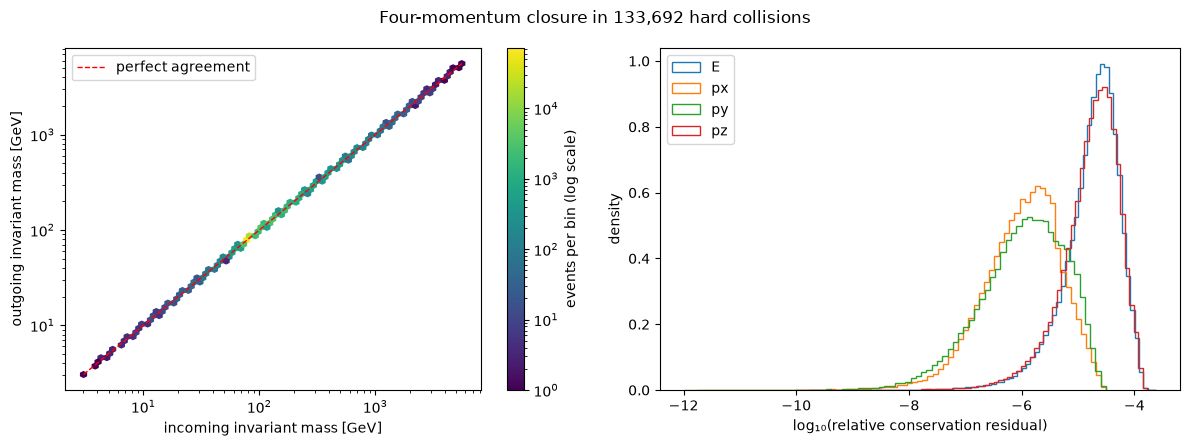

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

positive_mass = (mass_in > 0) & (mass_out > 0)
plot_limits = [
    min(mass_in[positive_mass].min(), mass_out[positive_mass].min()),
    max(mass_in[positive_mass].max(), mass_out[positive_mass].max()),
]
hexbin = axes[0].hexbin(
    mass_in[positive_mass], mass_out[positive_mass],
    gridsize=65, bins="log", mincnt=1, xscale="log", yscale="log",
)
axes[0].plot(plot_limits, plot_limits, "r--", linewidth=1, label="perfect agreement")
axes[0].set(xlabel="incoming invariant mass [GeV]", ylabel="outgoing invariant mass [GeV]")
axes[0].legend()
fig.colorbar(hexbin, ax=axes[0], label="events per bin (log scale)")

for field in ["E", "px", "py", "pz"]:
    log_residual = np.log10(np.clip(relative_residual[field], 1e-12, None))
    axes[1].hist(log_residual, bins=80, histtype="step", density=True, label=field)
axes[1].set(xlabel="log₁₀(relative conservation residual)", ylabel="density")
axes[1].legend()

fig.suptitle(f"Four-momentum closure in {len(lhe):,} hard collisions")
fig.tight_layout()
plt.show()

## Follow the event into `GenPart`

After the matrix element, the event generator evolves the hard particles through parton showering, hadronization, and decays. `GenPart_statusFlags` identifies roles in that history. Useful bits include `isHardProcess` (bit 7), `fromHardProcess` (bit 8), `isFirstCopy` (bit 12), and `isLastCopy` (bit 13). Status 1 means a stable final-state particle in the generator record; other numerical status codes are generator-dependent, so the named flags are usually easier to interpret.

The chosen event contains several successive copies of the $W$. `GenPart_genPartIdxMother` stores the index of each particle's parent; NanoAOD uses the traditional particle-physics term “mother” in this official branch name. We can select the last W copy and compare that parent four-vector with its **direct decay products**. This is a local conservation test that avoids double-counting the earlier copies.

In [12]:
# Read the detailed generator history only for the event selected above.
gen_branches = [
    "event", "GenPart_pdgId", "GenPart_status", "GenPart_statusFlags",
    "GenPart_genPartIdxMother", "GenPart_pt", "GenPart_eta",
    "GenPart_phi", "GenPart_mass",
]
gen = events.arrays(
    gen_branches,
    entry_start=event_index,
    entry_stop=event_index + 1,
    library="ak",
)[0]

FLAG_BITS = {
    7: "hard process",
    8: "from hard process",
    12: "first copy",
    13: "last copy",
    14: "last before FSR",
}

def has_flag(flags, bit):
    return bool(int(flags) & (1 << bit))

def selected_flag_names(flags):
    return ", ".join(name for bit, name in FLAG_BITS.items() if has_flag(flags, bit))

In [13]:
history_rows = []
for index in range(len(gen.GenPart_pdgId)):
    flags = gen.GenPart_statusFlags[index]
    if has_flag(flags, 7) or has_flag(flags, 8):
        history_rows.append([
            index,
            int(gen.GenPart_genPartIdxMother[index]),
            particle_name(gen.GenPart_pdgId[index]),
            int(gen.GenPart_pdgId[index]),
            int(gen.GenPart_status[index]),
            f"{float(gen.GenPart_pt[index]):.3f}",
            selected_flag_names(flags),
        ])

display_table(
    ["index", "parent index", "particle", "PDG ID", "status", "pT [GeV]", "selected flags"],
    history_rows,
)

| index | parent index | particle | PDG ID | status | pT [GeV] | selected flags |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | -1 | ū | -2 | 21 | 0.000 | hard process, from hard process, first copy, last copy |
| 1 | -1 | d | 1 | 21 | 0.000 | hard process, from hard process, last copy |
| 2 | 0 | W⁻ | -24 | 22 | 0.000 | hard process, from hard process, first copy |
| 3 | 2 | W⁻ | -24 | 44 | 2.758 | from hard process |
| 4 | 3 | W⁻ | -24 | 44 | 3.617 | from hard process |
| 5 | 4 | W⁻ | -24 | 44 | 4.438 | from hard process |
| 6 | 5 | W⁻ | -24 | 62 | 3.586 | from hard process, last copy |
| 7 | 6 | μ⁻ | 13 | 1 | 36.750 | hard process, from hard process, first copy, last copy |
| 8 | 6 | ν̄μ | -14 | 1 | 40.375 | hard process, from hard process, first copy, last copy |

## Display the decay chain

The Scikit-HEP [`particle`](https://github.com/scikit-hep/particle) package translates PDG IDs into particle names, while [`graphviz`](https://graphviz.readthedocs.io/) lays out the parent-to-child relationships as an inline SVG.

The helper below can draw the complete stored event or just the descendants of a chosen particle. Starting at the first $W$ copy gives a readable decay chain and excludes unrelated generator particles. Repeated $W$ nodes are meaningful: they are successive copies of the same particle as the generator evolves the event.

The Python `graphviz` package calls the system Graphviz `dot` renderer. The setup cell checks for it and installs it in Google Colab when necessary.

In [14]:
def pdg_name_from_library(pdg_id):
    """Return the PDG particle name, with a safe fallback for generator-specific IDs."""
    try:
        return Particle.from_pdgid(int(pdg_id)).name
    except ParticleNotFound:
        return f"PDG {int(pdg_id)}"

def descendant_indices(gen_particles, root_index):
    """Return root_index and all descendants linked through the stored parent indices."""
    parent_indices = np.asarray(ak.to_numpy(gen_particles.GenPart_genPartIdxMother), dtype=int)
    selected = {int(root_index)}
    while True:
        children = {index for index, parent_index in enumerate(parent_indices) if parent_index in selected}
        expanded = selected | children
        if expanded == selected:
            return selected
        selected = expanded

def draw_genpart_tree(gen_particles, root_index=None):
    """Draw GenPart parent links, optionally restricted to one particle's descendants."""
    particle_count = len(gen_particles.GenPart_pdgId)
    selected = (
        set(range(particle_count))
        if root_index is None
        else descendant_indices(gen_particles, root_index)
    )

    graph = Digraph(
        "genpart_decay",
        format="svg",
        graph_attr={"rankdir": "LR", "bgcolor": "transparent", "ranksep": "0.65"},
        node_attr={"shape": "box", "style": "rounded,filled", "fontname": "Helvetica"},
        edge_attr={"color": "#64748b", "arrowsize": "0.7"},
    )

    for index in sorted(selected):
        pdg_id = int(gen_particles.GenPart_pdgId[index])
        status = int(gen_particles.GenPart_status[index])
        pt_value = float(gen_particles.GenPart_pt[index])
        name = html.escape(pdg_name_from_library(pdg_id))

        if abs(pdg_id) in {23, 24, 25}:
            fill_color = "#fde68a"  # heavy bosons
        elif status == 1:
            fill_color = "#bbf7d0"  # stable generator particles
        else:
            fill_color = "#dbeafe"  # intermediate copies

        label = (
            f"<<B>{name}</B><BR/>"
            f"<FONT POINT-SIZE='10'>index {index} · PDG {pdg_id} · status {status}<BR/>"
            f"pT = {pt_value:.2f} GeV</FONT>>"
        )
        graph.node(str(index), label=label, fillcolor=fill_color)

    for child_index in sorted(selected):
        parent_index = int(gen_particles.GenPart_genPartIdxMother[child_index])
        if parent_index in selected:
            graph.edge(str(parent_index), str(child_index))

    return graph

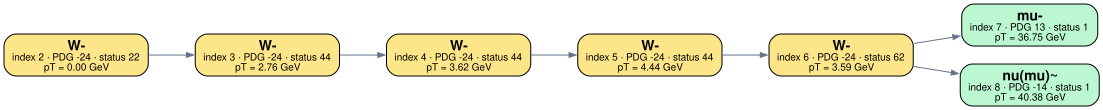

In [15]:
first_w_index = next(
    index for index in range(len(gen.GenPart_pdgId))
    if abs(int(gen.GenPart_pdgId[index])) == 24 and has_flag(gen.GenPart_statusFlags[index], 12)
)

draw_genpart_tree(gen, root_index=first_w_index)

In [16]:
# Follow the W copy chain, then compare the last copy with its direct decay products.
w_descendants = descendant_indices(gen, first_w_index)
last_w_indices = [
    index for index in sorted(w_descendants)
    if abs(int(gen.GenPart_pdgId[index])) == 24 and has_flag(gen.GenPart_statusFlags[index], 13)
]
assert len(last_w_indices) == 1
w_index = last_w_indices[0]
decay_product_indices = np.flatnonzero(ak.to_numpy(gen.GenPart_genPartIdxMother == w_index))
assert sorted(abs(int(gen.GenPart_pdgId[index])) for index in decay_product_indices) == [13, 14]

def gen_four_vector(index):
    pt_value = float(gen.GenPart_pt[index])
    eta_value = float(gen.GenPart_eta[index])
    phi_value = float(gen.GenPart_phi[index])
    mass_value = float(gen.GenPart_mass[index])
    return np.array([
        np.sqrt((pt_value * np.cosh(eta_value))**2 + mass_value**2),
        pt_value * np.cos(phi_value),
        pt_value * np.sin(phi_value),
        pt_value * np.sinh(eta_value),
    ])

w_p4 = gen_four_vector(w_index)
decay_products_p4 = np.sum([gen_four_vector(index) for index in decay_product_indices], axis=0)
decay_residual = w_p4 - decay_products_p4

decay_rows = [
    [particle_name(gen.GenPart_pdgId[w_index]), *[f"{value:+.6f}" for value in w_p4]],
    [" + ".join(particle_name(gen.GenPart_pdgId[index]) for index in decay_product_indices),
     *[f"{value:+.6f}" for value in decay_products_p4]],
    ["parent − decay products", *[f"{value:+.6f}" for value in decay_residual]],
]
display_table(["system", "E [GeV]", "px [GeV]", "py [GeV]", "pz [GeV]"], decay_rows)
print("Largest relative W-decay residual:", f"{np.max(abs(decay_residual) / w_p4[0]):.2e}")

| system | E [GeV] | px [GeV] | py [GeV] | pz [GeV] |
| --- | --- | --- | --- | --- |
| W⁻ | +80.680680 | +3.476186 | -0.880387 | -4.032762 |
| μ⁻ + ν̄μ | +80.686852 | +3.523133 | -0.918157 | -4.017621 |
| parent − decay products | -0.006172 | -0.046947 | +0.037770 | -0.015140 |

Largest relative W-decay residual: 5.82e-04


## Takeaways

- The 13 TeV proton collision does **not** put 13 TeV into each hard interaction. The two incoming partons carry fractions $x_1$ and $x_2$ of the beam momenta.
- The `LHEPart` incoming and outgoing systems have matching $E$, $p_x$, $p_y$, $p_z$, and invariant mass event by event.
- Small residuals remain because the NanoAOD file stores reduced-precision kinematic values.
- Generator histories contain successive copies and branches. Conservation should be tested either across the complete LHE hard interaction or locally at a well-defined parent-to-decay-products vertex—not by summing every `GenPart` row.